In [1]:
import pandas as pd

In [9]:
df = pd.read_csv('/content/data.csv')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Experience Years  40 non-null     float64
 1   Salary            40 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 772.0 bytes


In [11]:
df.isnull().sum()

,0
Experience Years,0
Salary,0


In [13]:
print("No missing values found in the DataFrame. There's no need to replace null values.")

No missing values found in the DataFrame. There's no need to replace null values.


In [14]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [15]:
df

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525
5,2.2,39891
6,2.5,48266
7,2.9,56642
8,3.0,60150
9,3.2,54445


In [17]:
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
le = LabelEncoder()

# Note: Your current data is already numerical.
# If you had a categorical column named 'Category', you would use:
# df['Category_Encoded'] = le.fit_transform(df['Category'])

print("LabelEncoder initialized. To apply it, use: le.fit_transform(df['column_name'])")

LabelEncoder initialized. To apply it, use: le.fit_transform(df['column_name'])


In [21]:
le.fit_transform(df['Salary'])

array([ 1,  3,  5,  0,  4,  2,  6,  9, 15,  7, 19, 14, 12, 16, 18,  8, 10,
       11, 13, 17, 20, 22, 21, 25, 24, 23, 29, 27, 26, 28, 30, 31, 36, 34,
       33, 32, 37, 35, 39, 38])

In [22]:
# Separating independent variable (X) and dependent variable (y)
X = df[['Experience Years']]
y = df['Salary']

print('Independent variable (X):')
display(X.head())
print('\nDependent variable (y):')
display(y.head())

Independent variable (X):


,Experience Years
0,1.1
1,1.2
2,1.3
3,1.5
4,2.0



Dependent variable (y):


,Salary
0,39343
1,42774
2,46205
3,37731
4,43525


In [24]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into Training set and Test set
# Using 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (32, 1)
X_test shape: (8, 1)
y_train shape: (32,)
y_test shape: (8,)


In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Initialize the models
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
svm = SVR(kernel='rbf')
knn = KNeighborsRegressor(n_neighbors=5)

# Train the models
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

print("All models have been trained successfully!")

All models have been trained successfully!


In [26]:
# Making predictions on the test set
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_svm = svm.predict(X_test)
y_pred_knn = knn.predict(X_test)

# Create a comparison DataFrame
import pandas as pd
results = pd.DataFrame({
    'Actual': y_test,
    'Linear Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'SVM': y_pred_svm,
    'KNN': y_pred_knn
})

display(results.head())

,Actual,Linear Regression,Decision Tree,Random Forest,SVM,KNN
19,61111,69052.390902,59095.0,60429.03,65262.077810,62928.6
16,56957,64348.375266,63218.0,61473.50,65259.302116,59918.8
15,55794,64348.375266,63218.0,61473.50,65259.302116,59918.8
26,93940,83164.437811,81363.0,82103.73,65270.802350,85677.8
4,43525,45532.312721,39891.0,40125.01,65255.043557,42973.4


In [27]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Define a function to calculate metrics
def get_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'R2 Score': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
    }

# Calculate metrics for all models
metrics_list = [
    get_metrics(y_test, y_pred_lr, 'Linear Regression'),
    get_metrics(y_test, y_pred_dt, 'Decision Tree'),
    get_metrics(y_test, y_pred_rf, 'Random Forest'),
    get_metrics(y_test, y_pred_svm, 'SVM'),
    get_metrics(y_test, y_pred_knn, 'KNN')
]

# Create a summary DataFrame
evaluation_df = pd.DataFrame(metrics_list)
display(evaluation_df.sort_values(by='R2 Score', ascending=False))

,Model,R2 Score,MAE,RMSE
4,KNN,0.972647,3052.125000,3757.534606
2,Random Forest,0.934098,4920.508750,5832.428712
0,Linear Regression,0.906858,6419.911069,6933.810725
1,Decision Tree,0.905437,6111.750000,6986.491287
3,SVM,-0.075197,19184.425942,23558.231925


In [30]:
models = {
    'Linear Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'SVM': svm,
    'KNN': knn
}

loop_metrics = []

for name, model in models.items():
    predictions = model.predict(X_test)
    loop_metrics.append({
        'Model': name,
        'R2 Score': r2_score(y_test, predictions),
        'MAE': mean_absolute_error(y_test, predictions),
        'RMSE': np.sqrt(mean_squared_error(y_test, predictions))
    })

evaluation_loop_df = pd.DataFrame(loop_metrics)
display(evaluation_loop_df.sort_values(by='R2 Score', ascending=False))

,Model,R2 Score,MAE,RMSE
4,KNN,0.972647,3052.125000,3757.534606
2,Random Forest,0.934098,4920.508750,5832.428712
0,Linear Regression,0.906858,6419.911069,6933.810725
1,Decision Tree,0.905437,6111.750000,6986.491287
3,SVM,-0.075197,19184.425942,23558.231925


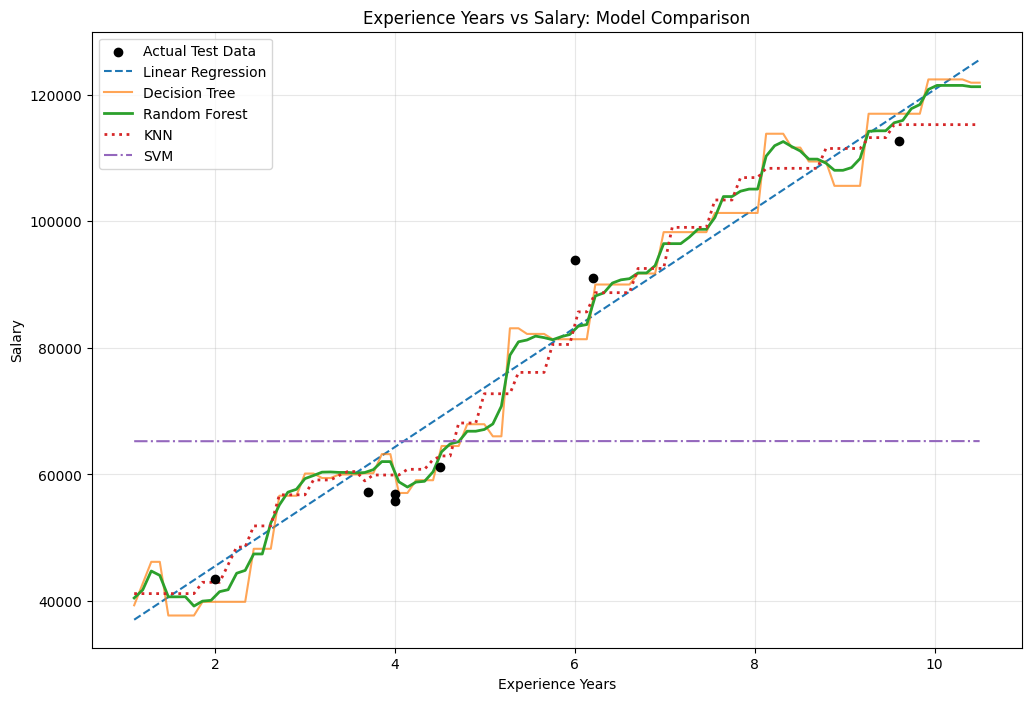

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create a range of values for a smooth curve and use a DataFrame to keep feature names
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_df = pd.DataFrame(X_range, columns=['Experience Years'])

plt.figure(figsize=(12, 8))

# Plot Actual Data
plt.scatter(X_test, y_test, color='black', label='Actual Test Data', zorder=5)

# Plot Predictions for each model using the DataFrame with feature names
plt.plot(X_range, lr.predict(X_range_df), label='Linear Regression', linestyle='--')
plt.plot(X_range, dt.predict(X_range_df), label='Decision Tree', alpha=0.7)
plt.plot(X_range, rf.predict(X_range_df), label='Random Forest', linewidth=2)
plt.plot(X_range, knn.predict(X_range_df), label='KNN', linestyle=':', linewidth=2)
plt.plot(X_range, svm.predict(X_range_df), label='SVM', linestyle='-.')

plt.title('Experience Years vs Salary: Model Comparison')
plt.xlabel('Experience Years')
plt.ylabel('Salary')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [33]:
# Final Model Comparison Summary
comparison_summary = evaluation_loop_df.sort_values(by='R2 Score', ascending=False).reset_index(drop=True)

print("Model Performance Ranking:")
display(comparison_summary)

# Quick conclusion based on metrics
best_model = comparison_summary.iloc[0]['Model']
print(f"\nConclusion: The {best_model} model is the most accurate for this dataset based on the R2 Score.")

Model Performance Ranking:


,Model,R2 Score,MAE,RMSE
0,KNN,0.972647,3052.125000,3757.534606
1,Random Forest,0.934098,4920.508750,5832.428712
2,Linear Regression,0.906858,6419.911069,6933.810725
3,Decision Tree,0.905437,6111.750000,6986.491287
4,SVM,-0.075197,19184.425942,23558.231925



Conclusion: The KNN model is the most accurate for this dataset based on the R2 Score.


In [34]:
import joblib

# Save the best model (KNN) to a pickle file
model_filename = 'best_model.pkl'
joblib.dump(knn, model_filename)

print(f'Model saved successfully as {model_filename}')

Model saved successfully as best_model.pkl
